# Учимся работе с данными - от загрузки до моделирования

## Выводы по упражнению:


список фич с высокой корреляцией в списке: high_corr_list

сначала прогнал обе модели без удаления коррелированных столбцов,  у knn почти 1, у лог рег тоже очень близко.

Потом удалил столбцы с корр выше 0.85.
Результаты особо не изменились.

Настроил логи в csv - logs.csv в этой же папке.

Добавил график на plotly - понравилось больше чем seaborn - можно мышкой водить и смотреть значения.

в импортах добавил там строку чтобы pip установку сделать в нужную папку, долго не мог понять чего не видно импортов :)

Весь ноутбук запускается полностью (по крайней мере локально ОК), только не делал проверки если открыт csv файл отдельно экселем

Технически сами фичи в таблице почти все математические (радиусы, расстояния, площади ..) и логично, что например площадь связана с радиусом т.к. меряют их доктора кружками.  Маловато самих записей чтобы кросс валидацию сделать на больше частей и, чтобы в каждом фолде было хотябы по пару тысяч записей, тогда усреднились бы метрики. а так почти 100% точность получается. Ну лог рег чуть отстает от knn в моем случае.

Для прода, наверное можно было бы чуть увеличить recall по отношению к precision, чтобы спорные/пограничные случаи были просмотрены доктором.


In [217]:
#YOUR CODE HERE


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px  # added to draw with plotly
import sys # to update plotly dependencies

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

!{sys.executable} -m pip install nbformat --upgrade


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\User\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [218]:
# df_raw=pd.read_csv('../datasets/breast_can_wiscons.csv')

df_path = '../datasets/breast_can_wiscons.csv'

# read col names only
cols = pd.read_csv(df_path, nrows=0).columns.tolist()

# which cols to skip and which to import
cols_to_skip = ['id', 'Unnamed: 32']
cols_to_load = [col for col in cols if col not in cols_to_skip]

# load csv
df_raw = pd.read_csv(df_path, usecols=cols_to_load)

print(f'rows:{df_raw.shape[0]}  columns:{df_raw.shape[1]}')
df_raw.head()

rows:569  columns:31


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119
1,M,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089
2,M,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088
3,M,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173
4,M,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077


In [219]:
# =====================
# EDA section
# =====================

# config

target_col = 'diagnosis'

# encoding target as good B = 0, bad M = 1
encoding_map = {'M': 1, 'B': 0}
df_raw[target_col] = df_raw[target_col].map(encoding_map)


# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Readability
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)


# function to get one column stats
def column_stats_table(df_check, column_check):
    counts = df_check[column_check].value_counts()
    percentages = df_check[column_check].value_counts(normalize=True) * 100

    column_stats = pd.DataFrame({
        'value': counts.index,
        'count': counts.values,
        'percentage': percentages.values
    })
    return column_stats


def distribution_plot(df_check):
    plt.rc('axes', titlesize=16)
    df_check.hist(figsize=(18, 11), xlabelsize=10, ylabelsize=10)
    plt.tight_layout(h_pad=3.0, w_pad=2.0)


In [220]:
column_stats_table(df_raw, target_col)

,value,count,percentage
0,0,357,62.742
1,1,212,37.258


In [221]:
# =====================
# 1. Statistics
# =====================

# Separate numeric and categorical columns
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
text_cols = df_raw.select_dtypes(include=['object']).columns.tolist()


# numeric cols overview
print('\n=== Numeric cols overview ===')
print(df_raw[numeric_cols].describe())

# Median values
print('\n=== Median ===')
print(df_raw[numeric_cols].median())

# text cols
if text_cols:
    print('\n=== Text cols overview ===')
    for col in text_cols:
        print(column_stats_table(df_raw, col))


=== Numeric cols overview ===
       diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
count    569.000      569.000       569.000         569.000    569.000   
mean       0.373       14.127        19.290          91.969    654.889   
std        0.484        3.524         4.301          24.299    351.914   
min        0.000        6.981         9.710          43.790    143.500   
25%        0.000       11.700        16.170          75.170    420.300   
50%        0.000       13.370        18.840          86.240    551.100   
75%        1.000       15.780        21.800         104.100    782.700   
max        1.000       28.110        39.280         188.500   2501.000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count          569.000           569.000         569.000              569.000   
mean             0.096             0.104           0.089                0.049   
std              0.014             0.053           0.080   

In [222]:
# Statistics grouped by target variable
if target_col:
    print(f'\n=== statistics grouped by {target_col} ===')
    for col in numeric_cols[:10]:  # calculate for 10 columns of df
        print(f'\n--- {col} ---')
        print(df_raw.groupby(target_col)[col].agg(['min', 'max','mean', 'median', 'std']))


=== statistics grouped by diagnosis ===

--- diagnosis ---
           min  max  mean  median   std
diagnosis                              
0            0    0 0.000   0.000 0.000
1            1    1 1.000   1.000 0.000

--- radius_mean ---
             min    max   mean  median   std
diagnosis                                   
0          6.981 17.850 12.147  12.200 1.781
1         10.950 28.110 17.463  17.325 3.204

--- texture_mean ---
             min    max   mean  median   std
diagnosis                                   
0          9.710 33.810 17.915  17.390 3.995
1         10.380 39.280 21.605  21.460 3.779

--- perimeter_mean ---
             min     max    mean  median    std
diagnosis                                      
0         43.790 114.600  78.075  78.180 11.807
1         71.900 188.500 115.365 114.200 21.855

--- area_mean ---
              min      max    mean  median     std
diagnosis                                         
0         143.500  992.100 462.790 458.4

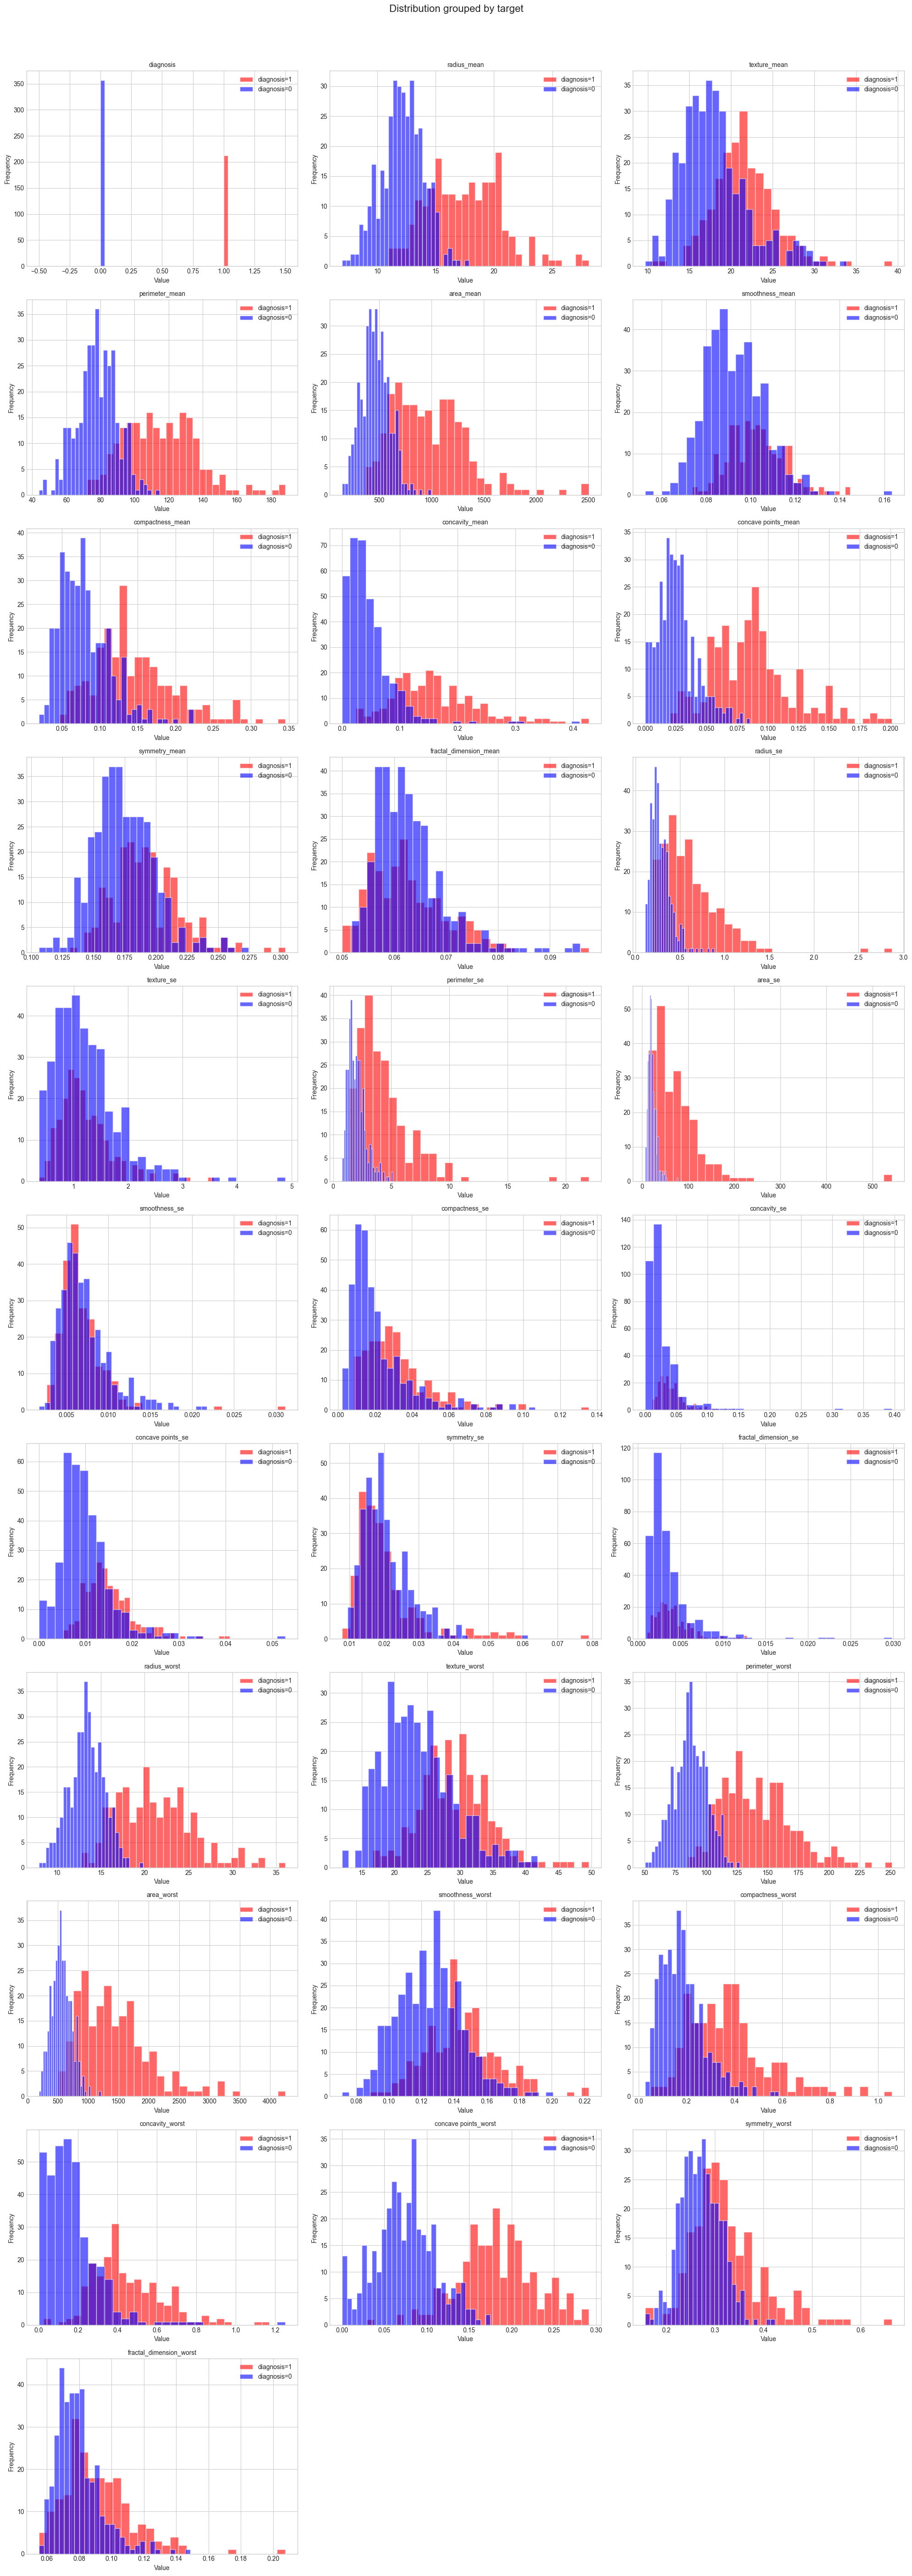

In [223]:

# =====================
# 2. Histograms with grouping by target
# =====================

if target_col:
    # Select numeric cols
    # exclude_cols = ['id', 'Unnamed: 32'] # this already skipped in config
    plot_cols = [col for col in numeric_cols]

    # Determine grid size
    n_cols = 3
    n_rows = (len(plot_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(plot_cols):
        if idx < len(axes):
            # Get unique target values for coloring
            target_values = df_raw[target_col].unique()
            colors = ['red', 'blue', 'green']  #  'orange', 'purple'

            for i, val in enumerate(target_values):
                subset = df_raw[df_raw[target_col] == val]
                axes[idx].hist(subset[col], bins=30, alpha=0.6,
                             label=f'{target_col}={val}',
                             color=colors[i % len(colors)])

            axes[idx].set_title(col, fontsize=10)
            axes[idx].legend(fontsize=10)
            axes[idx].set_xlabel('Value')
            axes[idx].set_ylabel('Frequency')

    # Remove empty subplots
    for idx in range(len(plot_cols), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle('Distribution grouped by target', fontsize=16, y=1.02)
    plt.show()
else:
    print('Target column not defined.')

> Используя boxplots и группировку по целевой переменной, попробуйте предположить, по каким признакам наиболее удобно было бы отделить злокачественные новообразования от доброкачественных.

Чисто визуально, фичи, где меньше наложений (розовых) - там легче разделить на синие (B) и красные (М) диагнозы. Ну и где явно формируются 2 вершины на графике.
Пример `concave points worst` (третий с конца)

Дополнительно визуализация с плотли (ниже), там в верхней части доп "вид сверху" тоже помогает заметить наложения или раздельные признаки


In [224]:
# Plotly render

PLOT_WIDTH = 800
PLOT_HEIGHT = 600

for col in numeric_cols[:5]: # columns to render (total cols = 31)
    # Overlayed histo
    fig = px.histogram(
        df_raw,
        x=col,
        color=target_col,
        barmode='overlay',
        opacity=0.6,
        color_discrete_sequence=['#E27170', '#5A9BD5' ], # less saturated colors
        title=f'Histogram: {col} grouped by {target_col}',
        marginal='rug', # 'box'  'histogram'  'rug'
        labels={col: 'Value', target_col: 'Class'}, # added to minimize hover info
        nbins=100
    )

    # hover tips and size adjustments
    fig.update_layout(
        hovermode='x unified',
        yaxis_title='Frequency',
        width=PLOT_WIDTH,
        height=PLOT_HEIGHT,
        bargap=0.05,
    )
    fig.show()

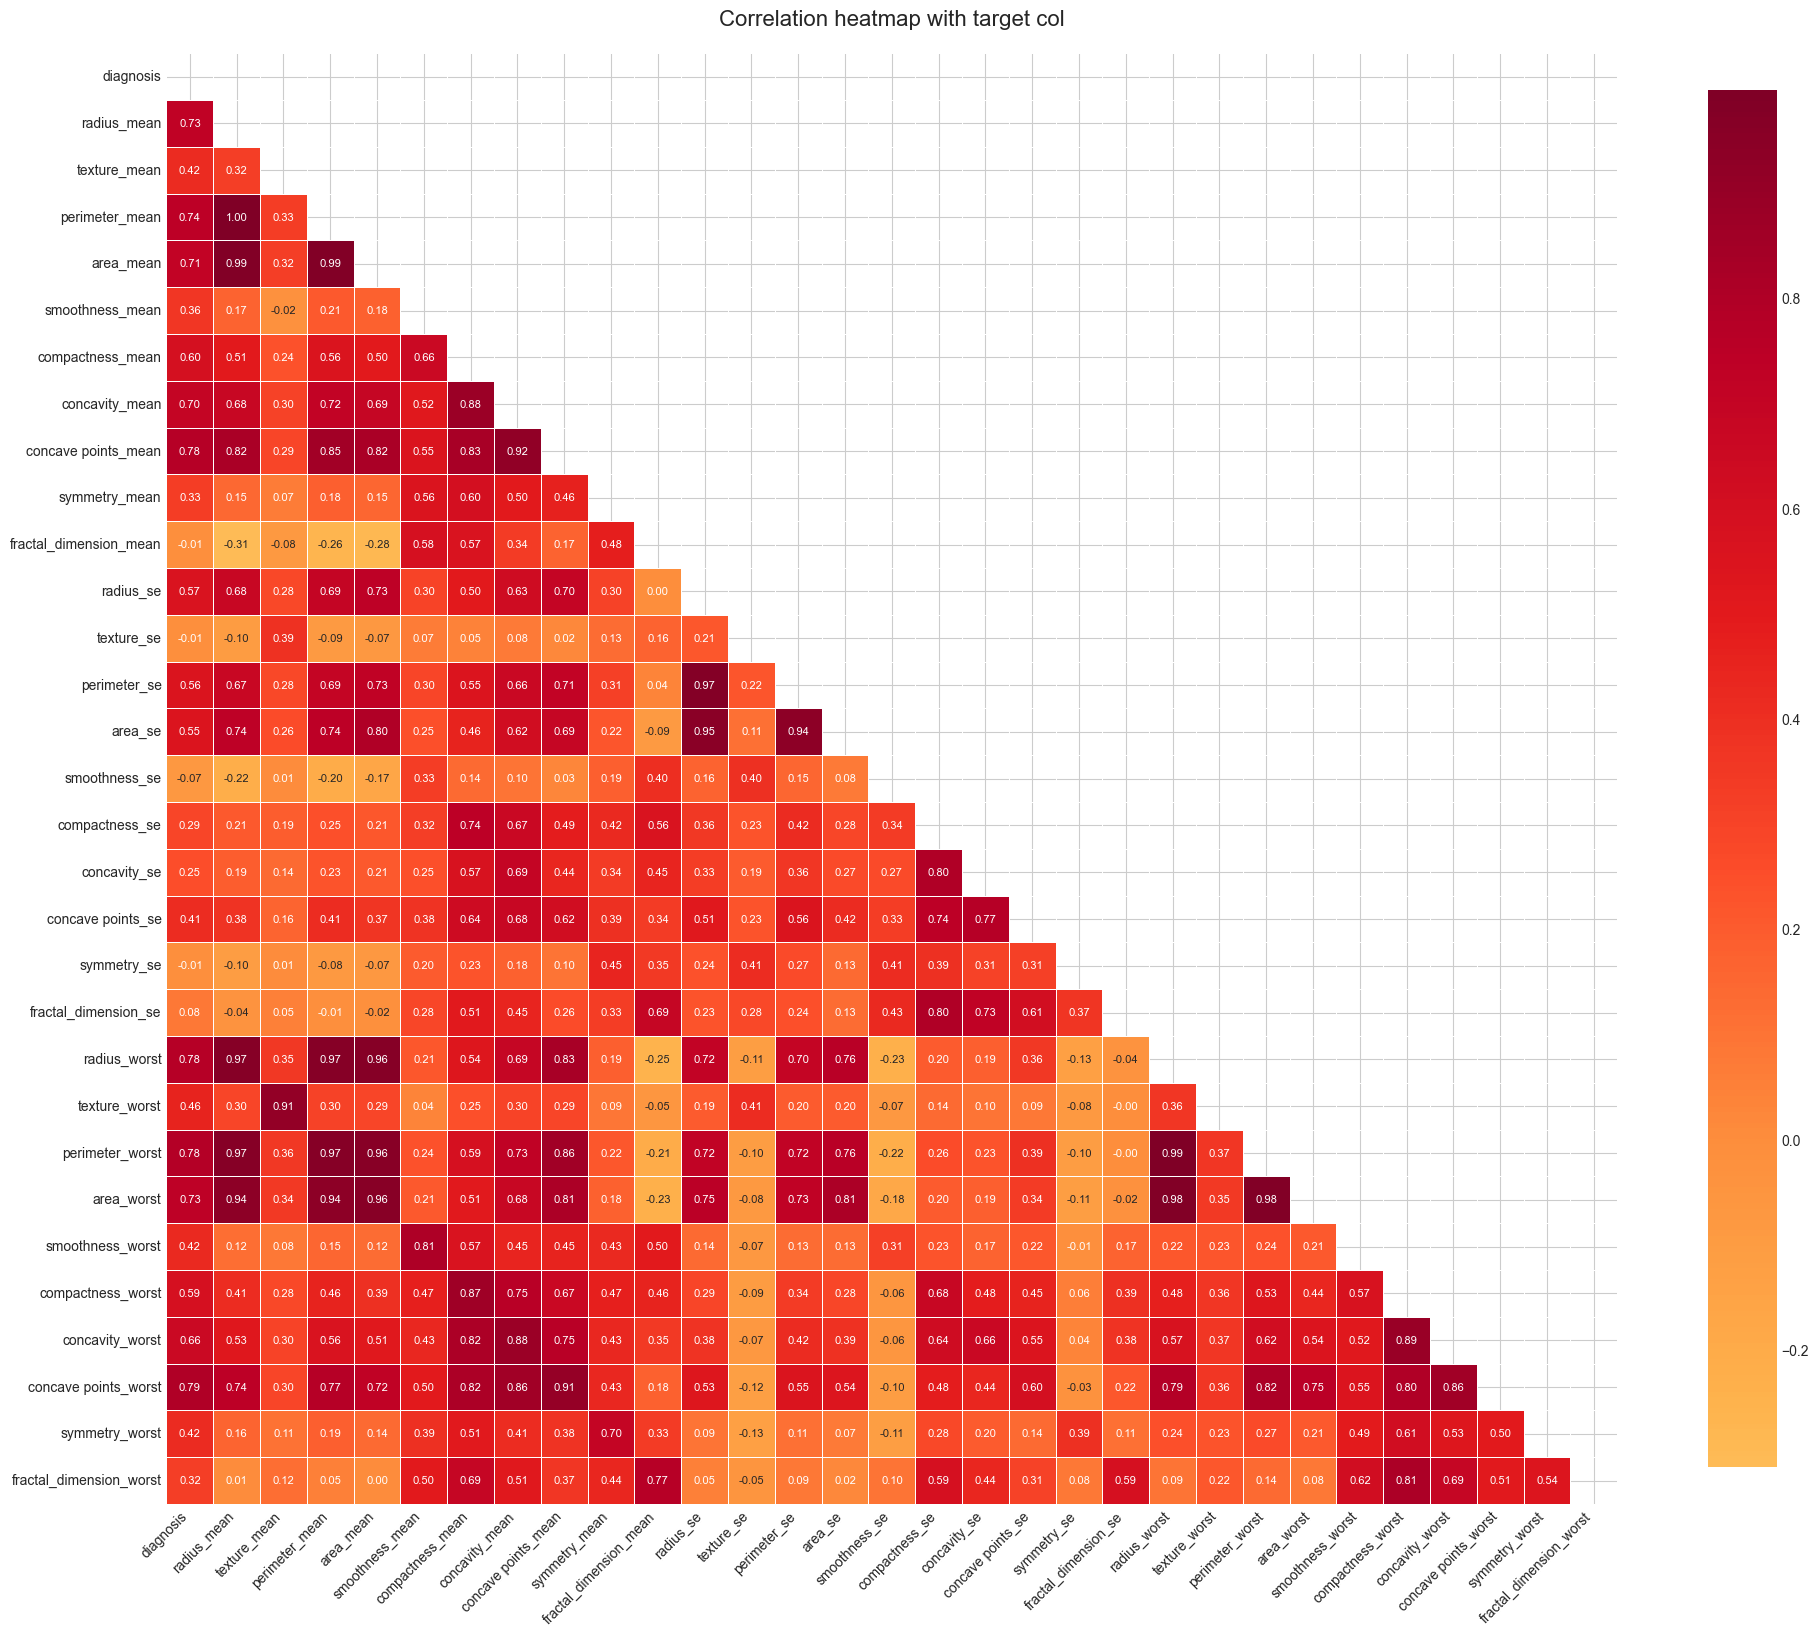


=== Strong corr (> 0.85) ===
radius_mean <-> perimeter_mean: 0.998
radius_worst <-> perimeter_worst: 0.994
radius_mean <-> area_mean: 0.987
perimeter_mean <-> area_mean: 0.987
radius_worst <-> area_worst: 0.984
perimeter_worst <-> area_worst: 0.978
radius_se <-> perimeter_se: 0.973
perimeter_mean <-> perimeter_worst: 0.970
radius_mean <-> radius_worst: 0.970
perimeter_mean <-> radius_worst: 0.969
radius_mean <-> perimeter_worst: 0.965
area_mean <-> radius_worst: 0.963
area_mean <-> area_worst: 0.959
area_mean <-> perimeter_worst: 0.959
radius_se <-> area_se: 0.952
perimeter_mean <-> area_worst: 0.942
radius_mean <-> area_worst: 0.941
perimeter_se <-> area_se: 0.938
concavity_mean <-> concave points_mean: 0.921
texture_mean <-> texture_worst: 0.912
concave points_mean <-> concave points_worst: 0.910
compactness_worst <-> concavity_worst: 0.892
concavity_mean <-> concavity_worst: 0.884
compactness_mean <-> concavity_mean: 0.883
compactness_mean <-> compactness_worst: 0.866
concavity_mea

In [225]:
# =====================
# 3. Correlation Heatmap
# =====================

corr_matrix = df_raw[numeric_cols].corr()


plt.figure(figsize=(20, 18))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',  # 'RdBu_r' 'YlOrRd'
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            annot_kws={'size': 8})

plt.title('Correlation heatmap with target col', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



threshold = 0.85
print(f'\n=== Strong corr (> {threshold}) ===')
strong_corr = []
correlated_cols = set()

for c in range(len(corr_matrix.columns)):
    for n in range(c+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[c, n]
        if abs(corr_val) > threshold:
            col1 = corr_matrix.columns[c]
            col2 = corr_matrix.columns[n]

            strong_corr.append((col1, col2, corr_val))
            # check for target col
            if col1 != target_col and col2 != target_col:
                correlated_cols.add(col2)

# high corr candidates to drop -  list
high_corr_list = list(correlated_cols)

# Sort pairs
strong_corr.sort(key=lambda x: abs(x[2]), reverse=True)
for feat1, feat2, corr_val in strong_corr:
    print(f'{feat1} <-> {feat2}: {corr_val:.3f}')

print(f'\nHighly correlated cols to drop count: {len(high_corr_list)}')
print(f'Columns: {high_corr_list}')


# check corr with target
if target_col and target_col in corr_matrix.columns:
    print('\nMost correlated with target')
    target_corr = corr_matrix[target_col].drop(target_col, errors='ignore')
    target_corr_sorted = target_corr.abs().sort_values(ascending=False)

    for col in target_corr_sorted.index:
        corr_val = target_corr[col]
        if abs(corr_val) > 0.5:
            print(f'{col}: {corr_val:.3f}')


In [226]:

df_raw.head()


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.990,10.380,122.800,1001.000,0.118,0.278,0.300,0.147,0.242,0.079,1.095,0.905,8.589,153.400,0.006,0.049,0.054,0.016,0.030,0.006,25.380,17.330,184.600,2019.000,0.162,0.666,0.712,0.265,0.460,0.119
1,1,20.570,17.770,132.900,1326.000,0.085,0.079,0.087,0.070,0.181,0.057,0.543,0.734,3.398,74.080,0.005,0.013,0.019,0.013,0.014,0.004,24.990,23.410,158.800,1956.000,0.124,0.187,0.242,0.186,0.275,0.089
2,1,19.690,21.250,130.000,1203.000,0.110,0.160,0.197,0.128,0.207,0.060,0.746,0.787,4.585,94.030,0.006,0.040,0.038,0.021,0.022,0.005,23.570,25.530,152.500,1709.000,0.144,0.424,0.450,0.243,0.361,0.088
3,1,11.420,20.380,77.580,386.100,0.142,0.284,0.241,0.105,0.260,0.097,0.496,1.156,3.445,27.230,0.009,0.075,0.057,0.019,0.060,0.009,14.910,26.500,98.870,567.700,0.210,0.866,0.687,0.258,0.664,0.173
4,1,20.290,14.340,135.100,1297.000,0.100,0.133,0.198,0.104,0.181,0.059,0.757,0.781,5.438,94.440,0.011,0.025,0.057,0.019,0.018,0.005,22.540,16.670,152.200,1575.000,0.137,0.205,0.400,0.163,0.236,0.077


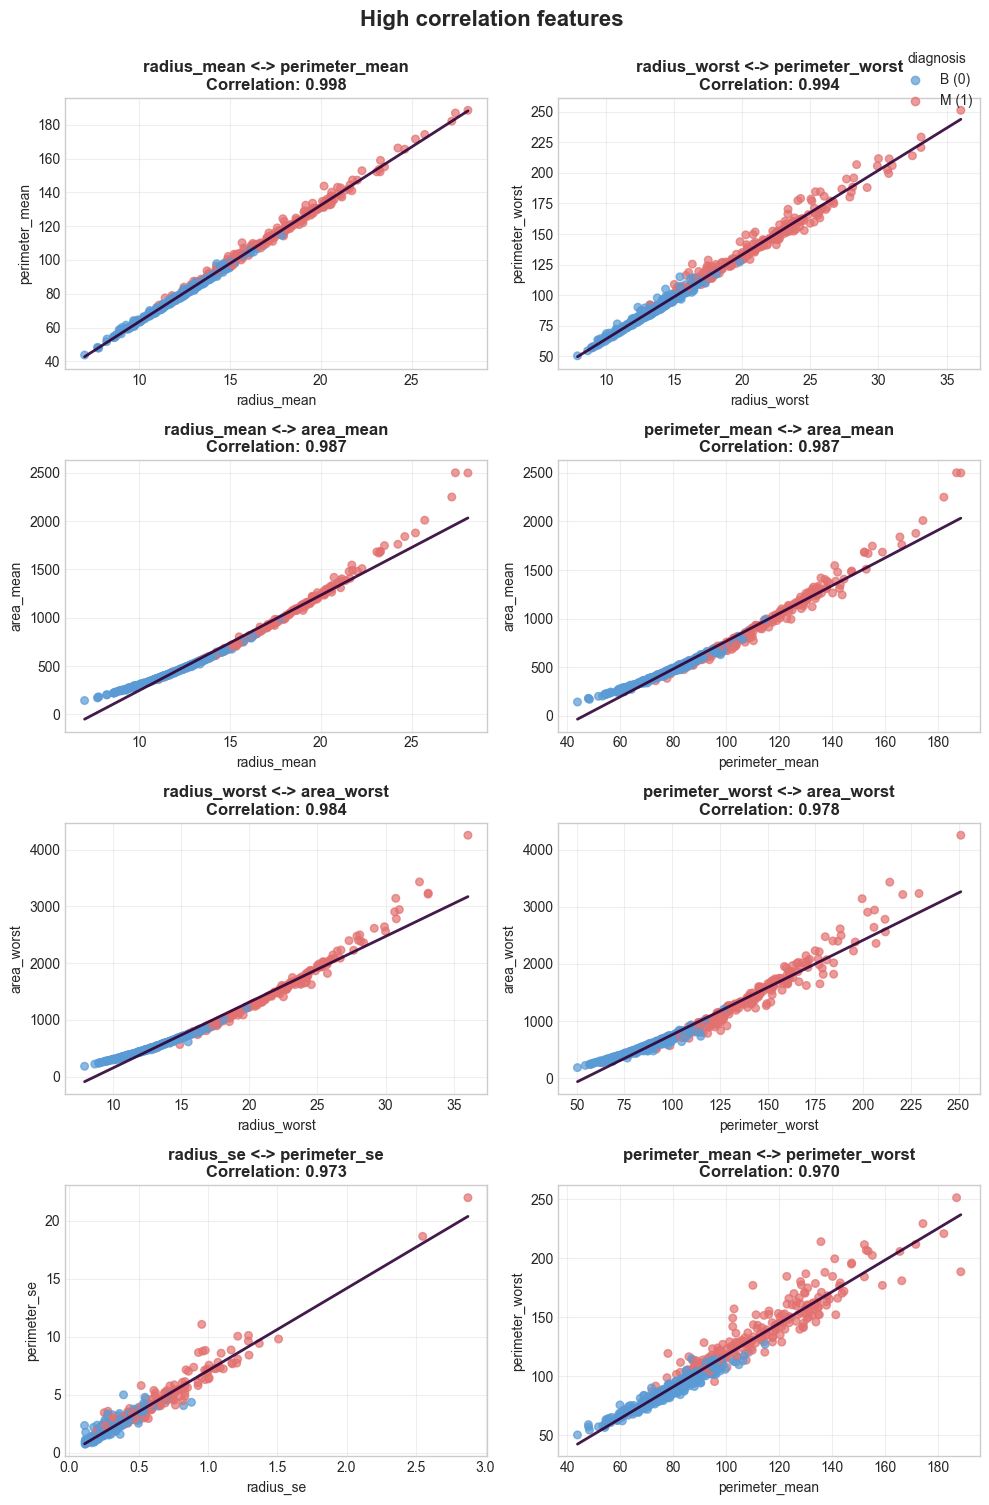


=== linear dependency check ===
radius_mean & perimeter_mean:
  Pearson: 0.998
  Spearman: 0.998
  -> Strong corr, can be dropped

radius_worst & perimeter_worst:
  Pearson: 0.994
  Spearman: 0.994
  -> Strong corr, can be dropped

radius_mean & area_mean:
  Pearson: 0.987
  Spearman: 1.000
  -> Strong corr, can be dropped

perimeter_mean & area_mean:
  Pearson: 0.987
  Spearman: 0.997
  -> Strong corr, can be dropped

radius_worst & area_worst:
  Pearson: 0.984
  Spearman: 0.999
  -> Strong corr, can be dropped

perimeter_worst & area_worst:
  Pearson: 0.978
  Spearman: 0.992
  -> Strong corr, can be dropped

radius_se & perimeter_se:
  Pearson: 0.973
  Spearman: 0.958
  -> Strong corr, can be dropped

perimeter_mean & perimeter_worst:
  Pearson: 0.970
  Spearman: 0.979
  -> Strong corr, can be dropped



In [227]:

# pair scatterplot check from 'strong_corr' list

if len(strong_corr) >= 8:
    top_pairs = strong_corr[:8]
else:
    strong_corr

if top_pairs:
    fig, axes = plt.subplots(4, 2, figsize=(10, 15))
    axes = axes.flatten()

    #  0 -> Blue (B) diagnosis, 1 -> Red (M)
    custom_cmap = mcolors.ListedColormap(['#5A9BD5', '#E27170'])

    for idx, (feat1, feat2, corr_val) in enumerate(top_pairs):
        if idx < len(axes):
            scatter = axes[idx].scatter(
                df_raw[feat1],
                df_raw[feat2],
                c=df_raw[target_col], # mapping colors based on target values
                alpha=0.7,
                cmap=custom_cmap,
                s=30
            )
            axes[idx].set_title(f'{feat1} <-> {feat2}\nCorrelation: {corr_val:.3f}', fontsize=12, fontweight='bold')

            # Dynamic regression line setup
            z = np.polyfit(df_raw[feat1], df_raw[feat2], 1)
            p = np.poly1d(z)
            x_line = np.linspace(df_raw[feat1].min(), df_raw[feat1].max(), 100)
            axes[idx].plot(
                x_line,
                p(x_line),
                color='#2e0136',
                linewidth=2,
                alpha=0.9,
                label='Trendline' # separate label
            )

            axes[idx].set_xlabel(feat1)
            axes[idx].set_ylabel(feat2)
            axes[idx].grid(True, alpha=0.3)

    # clean not used render blocks
    for i in range(len(top_pairs), len(axes)):
        fig.delaxes(axes[i])

    # legend labels
    handles, labels = scatter.legend_elements()
    fig.legend(handles, ['B (0)', 'M (1)'], loc='upper right', title=target_col, bbox_to_anchor=(0.99, 0.98))

    plt.suptitle('High correlation features ', fontsize=16, y=1.0, fontweight='bold')
    plt.tight_layout()
    plt.show()


# linear corr check
    print('\n=== linear dependency check ===')
    for feat1, feat2, corr_val in top_pairs[:8]:
        spearman_corr = df_raw[[feat1, feat2]].corr(method='spearman').iloc[0, 1]
        print(f'{feat1} & {feat2}:')
        print(f'  Pearson: {corr_val:.3f}')
        print(f'  Spearman: {spearman_corr:.3f}')
        if abs(corr_val - spearman_corr) < 0.1:
            print('  -> Strong corr, can be dropped')
        else:
            print('  -> keep in dataset')
        print()
else:
    print('No correlated pairs found')

In [228]:
# imports for knn and log reg

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                            f1_score, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')



In [229]:
# =====================
# Config
# =====================

RANDOM_STATE = 555
np.random.seed(RANDOM_STATE)

TEST_SIZE = 0.3
CV_FOLDS = 5
N_ITER_RANDOM_SEARCH = 30
LOGS_PATH = 'logs.csv'
scaler = StandardScaler()


In [230]:
# Train dataset preparation
# print(high_corr_list)

y = df_raw[target_col]
X = df_raw.drop(columns=[target_col] + high_corr_list, errors='ignore')  # high_corr_list



print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
# print(f'Class distribution: {np.bincount(y)}')

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'\nTrain size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test size: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)')
print(f'Train class distribution: {np.bincount(y_train)}')
print(f'Test class distribution: {np.bincount(y_test)}')

# Scale features

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Get feature names for later use
feature_names = X.columns.tolist()

Features shape: (569, 17)
Target shape: (569,)

Train size: 398 (69.9%)
Test size: 171 (30.1%)
Train class distribution: [250 148]
Test class distribution: [107  64]


In [231]:
# def functions to track metrics and log into csv

def evaluate_model(model, X_train, y_train, X_test, y_test):

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # predict probabilities for roc-auc
    y_train_proba = model.predict_proba(X_train)[:, 1] if hasattr(model, 'predict_proba') else None
    y_test_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Calculate metrics
    metrics = {
        'train_accuracy': round(accuracy_score(y_train, y_train_pred),4),
        'train_recall': round(recall_score(y_train, y_train_pred),4),
        'train_precision': round(precision_score(y_train, y_train_pred),4),
        'train_f1': round(f1_score(y_train, y_train_pred),4),
        'test_accuracy': round(accuracy_score(y_test, y_test_pred),4),
        'test_recall': round(recall_score(y_test, y_test_pred),4),
        'test_precision': round(precision_score(y_test, y_test_pred),4),
        'test_f1': round(f1_score(y_test, y_test_pred),4),
    }

    # Add roc auc
    if y_train_proba is not None and y_test_proba is not None:
        metrics['train_roc_auc'] = roc_auc_score(y_train, y_train_proba)
        metrics['test_roc_auc'] = roc_auc_score(y_test, y_test_proba)
        probas = (y_train_proba, y_test_proba)
    else:
        metrics['train_roc_auc'] = None
        metrics['test_roc_auc'] = None
        probas = (None, None)

    return metrics, (y_train_pred, y_test_pred), probas

def train_model_with_random_search(config, X_train, y_train, X_test, y_test,
                                   n_iter=N_ITER_RANDOM_SEARCH, cv=CV_FOLDS):

    model_name = config['model_name']
    model = config['model']
    param_dist = config['param_dist']

    print(f'\n{"="*60}')
    print(f'TRAINING {model_name}')
    print(f'{"="*60}')

    # pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])

    # Setup cross-validation
    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)

    # Setup random search
    random_search = RandomizedSearchCV(
        pipeline,
        param_distributions={f'classifier__{k}': v for k, v in param_dist.items()},
        n_iter=n_iter,
        cv=cv_strategy,
        scoring='f1_macro',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1
    )

    # Track time
    start_time = time.time()

    # random search
    print(f'Starting random search with {n_iter} iterations..')
    random_search.fit(X_train, y_train)

    # end time
    end_time = time.time()
    search_time = round(end_time - start_time, 1)

    print(f'Random search took {search_time:.2f} seconds')
    print(f'Best parameters: {random_search.best_params_}')
    print(f'Best cv score: {random_search.best_score_:.4f}')

    # best params
    best_model = random_search.best_estimator_
    best_params = random_search.best_params_

    # check model
    metrics, predictions, probas = evaluate_model(best_model, X_train, y_train, X_test, y_test)

    # Print results
    print(f'\n=== {model_name} RESULTS ===')
    print(f'Training metrics:')
    print(f'  Accuracy: {metrics["train_accuracy"]:.4f}')
    print(f'  Recall: {metrics["train_recall"]:.4f}')
    print(f'  Precision: {metrics["train_precision"]:.4f}')
    print(f'  F1: {metrics["train_f1"]:.4f}')
    if metrics['train_roc_auc']:
        print(f'  ROC-AUC: {metrics["train_roc_auc"]:.4f}')

    print(f'\nTest metrics:')
    print(f'  Accuracy: {metrics["test_accuracy"]:.4f}')
    print(f'  Recall: {metrics["test_recall"]:.4f}')
    print(f'  Precision: {metrics["test_precision"]:.4f}')
    print(f'  F1: {metrics["test_f1"]:.4f}')
    if metrics['test_roc_auc']:
        print(f'  ROC-AUC: {metrics["test_roc_auc"]:.4f}')

    return {
        'model_name': model_name,
        'best_params': best_params,
        'best_score': random_search.best_score_,
        'search_time': search_time,
        'metrics': metrics,
        'predictions': predictions,
        'probas': probas,
        'model': best_model
    }

def log_results(results, logs_path=LOGS_PATH):
    # Prepare row data
    row = {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'model': results['model_name'],
        'params': str(results['best_params']),
        'search_time_seconds': results['search_time'],
        'best_cv_score': round(results['best_score'],4),
        'train_accuracy': results['metrics']['train_accuracy'],
        'train_recall': results['metrics']['train_recall'],
        'train_precision': results['metrics']['train_precision'],
        'train_f1': results['metrics']['train_f1'],
        'train_roc_auc': results['metrics']['train_roc_auc'],
        'test_accuracy': results['metrics']['test_accuracy'],
        'test_recall': results['metrics']['test_recall'],
        'test_precision': results['metrics']['test_precision'],
        'test_f1': results['metrics']['test_f1'],
        'test_roc_auc': results['metrics']['test_roc_auc']
    }

    # Create new row for logs
    new_row_df = pd.DataFrame([row])

    # Append to csv
    try:
        # check if file exists
        existing_df = pd.read_csv(logs_path)
        updated_df = pd.concat([existing_df, new_row_df], ignore_index=True)
        updated_df.to_csv(logs_path, index=False)
        print(f'Results saved to {logs_path}')
    except FileNotFoundError:
        # create new file
        new_row_df.to_csv(logs_path, index=False)
        print(f'Created new file: {logs_path}')

    print(f'Logs added for {results["model_name"]}')

In [232]:
# =====================
# Train knn model
# =====================

# knn config
knn_config = {
    'model': KNeighborsClassifier(),
    'param_dist': {
        'n_neighbors': [3, 4, 5, 6, 8, 13, 19 ],  # 25, 50, 100
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev'],  # 'minkowski', 'chebyshev'
        'p': [1, 2],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
        'leaf_size': [20, 25, 30, 35, 40, 45]  # [10, 20, 30, 40, 50]
    },
    'model_name': 'KNN'
}

# Train knn
knn_results = train_model_with_random_search(
    knn_config,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    n_iter=144,
    cv=4
)

# Log results
log_results(knn_results)


TRAINING KNN
Starting random search with 144 iterations..
Fitting 4 folds for each of 144 candidates, totalling 576 fits
Random search took 4.30 seconds
Best parameters: {'classifier__weights': 'distance', 'classifier__p': 1, 'classifier__n_neighbors': 3, 'classifier__metric': 'euclidean', 'classifier__leaf_size': 45, 'classifier__algorithm': 'ball_tree'}
Best cv score: 0.9230

=== KNN RESULTS ===
Training metrics:
  Accuracy: 1.0000
  Recall: 1.0000
  Precision: 1.0000
  F1: 1.0000
  ROC-AUC: 1.0000

Test metrics:
  Accuracy: 0.9181
  Recall: 0.8594
  Precision: 0.9167
  F1: 0.8871
  ROC-AUC: 0.9657
Results saved to logs.csv
Logs added for KNN


In [233]:
# =====================
# Train logistic regression
# =====================

# Log reg config
logistic_config = {
    'model': LogisticRegression(random_state=RANDOM_STATE, max_iter=2000),
    'param_dist': {
        'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'solver': ['lbfgs', 'liblinear', 'saga'],
        'class_weight': ['balanced', None],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    'model_name': 'Log-Reg'
}

# Train
logistic_results = train_model_with_random_search(
    logistic_config,
    X_train_scaled,
    y_train,
    X_test_scaled,
    y_test,
    n_iter=144,
    cv=4
)

# Log results
log_results(logistic_results)


TRAINING Log-Reg
Starting random search with 144 iterations..
Fitting 4 folds for each of 144 candidates, totalling 576 fits
Random search took 25.80 seconds
Best parameters: {'classifier__solver': 'saga', 'classifier__penalty': 'elasticnet', 'classifier__l1_ratio': 0.3, 'classifier__class_weight': None, 'classifier__C': 1}
Best cv score: 0.9673

=== Log-Reg RESULTS ===
Training metrics:
  Accuracy: 0.9799
  Recall: 0.9595
  Precision: 0.9861
  F1: 0.9726
  ROC-AUC: 0.9978

Test metrics:
  Accuracy: 0.9708
  Recall: 0.9375
  Precision: 0.9836
  F1: 0.9600
  ROC-AUC: 0.9869
Results saved to logs.csv
Logs added for Log-Reg
